# Phishing Detection: Exploratory Data Analysis (EDA)

This notebook performs comprehensive EDA on the raw phishing datasets, including advanced feature extraction, behavioral density comparisons, feature gap analysis, and dimensionality reduction.

**Data Source:** `../data/raw/`  
**Output Reports:** `../reports/eda/`

In [14]:
!pip install pandas numpy matplotlib seaborn beautifulsoup4 wordcloud scikit-learn joblib openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
# Cell 2: Imports and Environment Setup
import os
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup, XMLParsedAsHTMLWarning
from wordcloud import WordCloud, STOPWORDS
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from joblib import Parallel, delayed

# Ignore HTML parsing warnings for raw web data
warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

# Set visual styling for the notebook
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

# Ensure output directory exists based on new project structure
REPORT_DIR = '../reports/eda/'
os.makedirs(REPORT_DIR, exist_ok=True)
print(f"Environment ready. Visualizations will be saved to: {REPORT_DIR}")

Environment ready. Visualizations will be saved to: ../reports/eda/


## 1. Data Loading & Pre-processing
We load the raw Excel files from the `data/raw/` directory, map the labels cleanly, and merge them into a unified dataset.

In [15]:
# Cell 4: Load and Merge Datasets
def load_data():
    print("Loading Excel files (.xlsx)...")
    path_url = '../data/raw/URL.xlsx'
    path_html = '../data/raw/html.xlsx'
    
    if not os.path.exists(path_url) or not os.path.exists(path_html):
        raise FileNotFoundError("Data files not found! Ensure URL.xlsx and html.xlsx are in PhishingDetection/data/raw/")

    df_url = pd.read_excel(path_url, engine='openpyxl')
    df_html = pd.read_excel(path_html, engine='openpyxl')

    # Standardize column names
    df_url.columns = ['Category', 'URL']
    df_html.columns = ['Category', 'HTML_Content']

    # Map Labels: Standardize string to catch "spam", "Spam", " spam "
    df_url['Category'] = df_url['Category'].astype(str).str.lower().str.strip()
    df_url['Label'] = df_url['Category'].apply(lambda x: 1 if 'spam' in x else (0 if 'ham' in x else None))

    # Merge and drop rows where Label mapping failed
    df = pd.concat([df_url[['Label', 'URL']], df_html[['HTML_Content']]], axis=1)
    return df.dropna(subset=['Label'])

df_master = load_data()
print(f"Master Dataset loaded successfully. Shape: {df_master.shape}")
display(df_master.head(3))

Loading Excel files (.xlsx)...
Master Dataset loaded successfully. Shape: (45373, 3)


,Label,URL,HTML_Content
0,1,logtelstra2021.ddnsking.com/0dfa1b53b835500696...,"<!DOCTYPE html>', '', '<html>', '<head>', '<me..."
1,1,dvsber.ru/modules/mod_ariimageslidersa/KRENK3N...,"<!DOCTYPE html><html dir=""ltr"" lang=""en""><head..."
2,1,kimsinc564.000webhostapp.com/notification.php?...,"<!DOCTYPE html PUBLIC ""-//W3C//DTD XHTML 1.0 T..."


## 2. Advanced Feature Extraction
Extracting structural URL behaviors, HTML link ratios, credential harvesting tags, and visible text content. We use `joblib` multiprocessing to handle the 45,000+ rows efficiently.

In [16]:
# Cell 6: Parallel Feature Extraction
def extract_url_features(url):
    url = str(url).lower()
    return {
        'url_length': len(url),
        'url_depth': url.count('/'),
        'num_dots': url.count('.'),
        'digit_ratio': sum(c.isdigit() for c in url) / len(url) if len(url) > 0 else 0,
        'has_ip': 1 if re.search(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', url) else 0,
        'brand_in_url': 1 if any(b in url for b in ['paypal', 'amazon', 'microsoft', 'google', 'netflix', 'apple']) else 0
    }

def extract_html_features(html_content):
    if pd.isna(html_content):
        return {'ext_link_ratio': 0, 'num_pass_inputs': 0, 'num_scripts': 0, 'text_length': 0, 'clean_text': ""}
    
    html_str = str(html_content).lower()
    soup = BeautifulSoup(html_str, 'html.parser')
    
    # External Link Analysis
    all_links = soup.find_all('a', href=True)
    ext_links = [l for l in all_links if l['href'].startswith('http')]
    link_ratio = len(ext_links) / len(all_links) if len(all_links) > 0 else 0
    
    # Extract Visible Text & Clean Encoding Artifacts
    for s in soup(["script", "style"]): s.decompose()
    visible_text = soup.get_text(separator=' ')
    clean_text = re.sub(r'[^a-zA-Z\s]', '', visible_text)
    clean_text = " ".join(clean_text.split())
    
    return {
        'ext_link_ratio': link_ratio,
        'num_pass_inputs': len(soup.find_all('input', {'type': 'password'})),
        'num_scripts': len(soup.find_all('script')),
        'num_iframes': len(soup.find_all('iframe')),
        'text_length': len(visible_text),
        'clean_text': clean_text[:2000] # Truncate for memory efficiency
    }

def process_row(row):
    u_feats = extract_url_features(row['URL'])
    h_feats = extract_html_features(row['HTML_Content'])
    visible_text = h_feats.pop('clean_text')
    return {**u_feats, **h_feats, 'Label': row['Label'], 'Text_Content': visible_text}

print(f"Processing {len(df_master)} rows in parallel...")
results = Parallel(n_jobs=-1)(delayed(process_row)(row) for _, row in df_master.iterrows())
df_final = pd.DataFrame(results)
print("Feature Extraction Complete!")
display(df_final.drop('Text_Content', axis=1).head(3))

Processing 45373 rows in parallel...
Feature Extraction Complete!


,url_length,url_depth,num_dots,digit_ratio,has_ip,brand_in_url,ext_link_ratio,num_pass_inputs,num_scripts,num_iframes,text_length,Label
0,61,2,2,0.409836,0,0,0.0,0,0,0,218,1
1,82,4,1,0.243902,0,0,0.0,0,0,0,0,1
2,63,1,3,0.095238,0,0,0.0,0,0,0,0,1


## 3. Behavioral Density & Feature Gap Analysis
Visualizing how Legitimate (0) and Phishing (1) websites differ structurally.

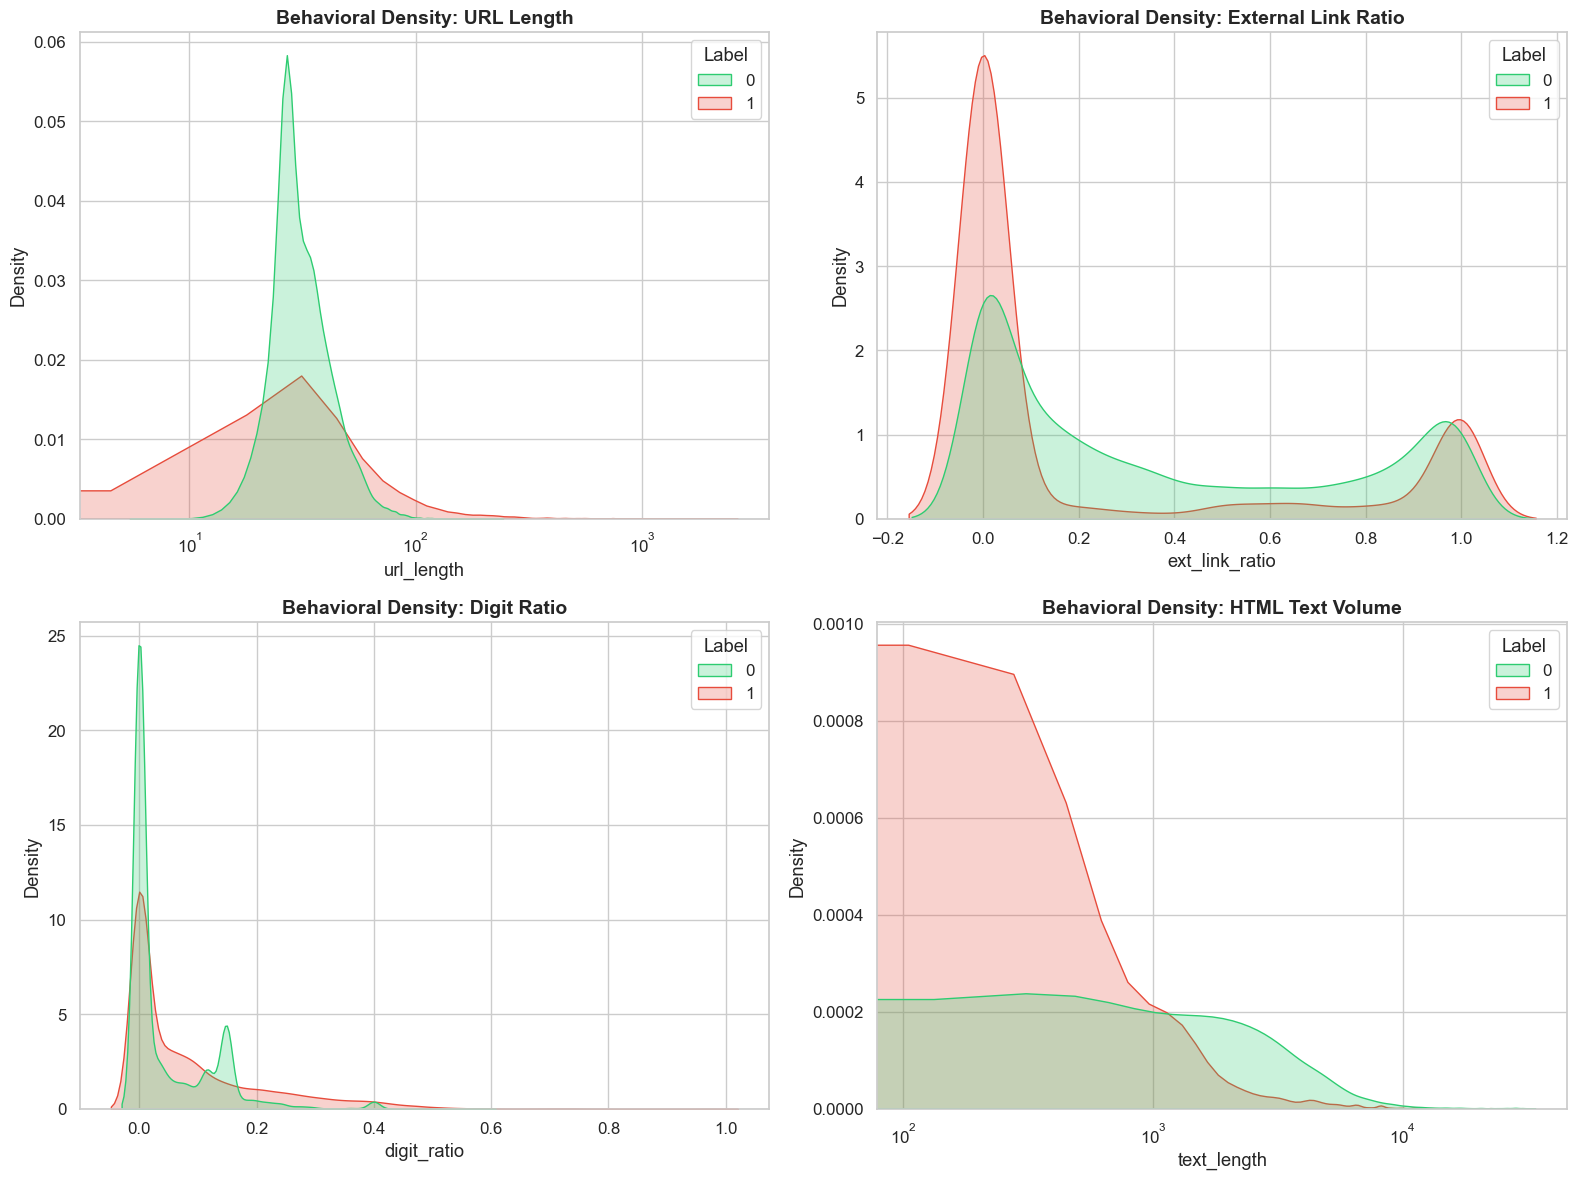

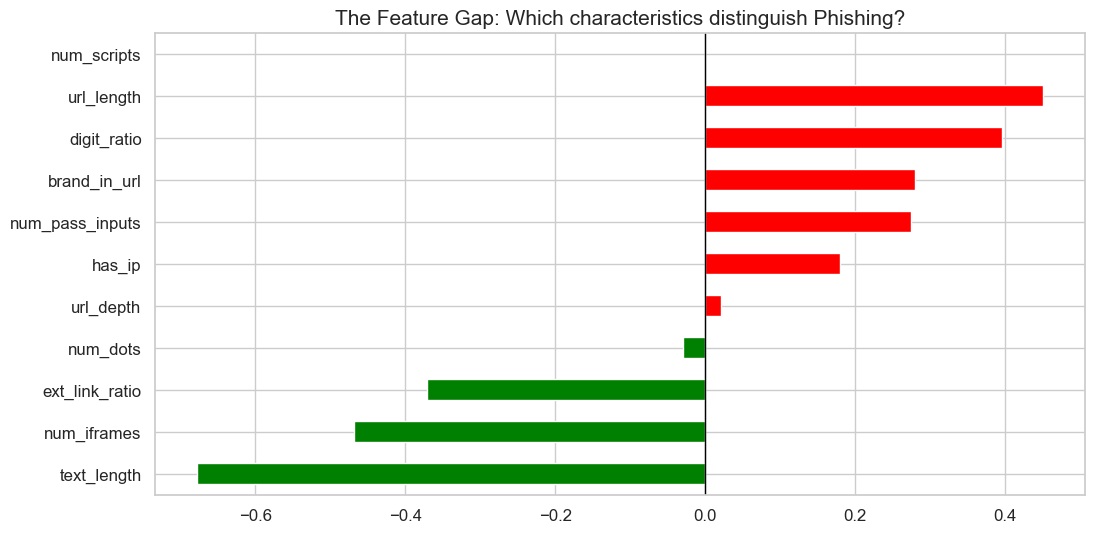

In [17]:
# Cell 8: Density and Gap Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
targets = [('url_length', 'URL Length'), ('ext_link_ratio', 'External Link Ratio'), 
           ('digit_ratio', 'Digit Ratio'), ('text_length', 'HTML Text Volume')]

for i, (feat, title) in enumerate(targets):
    ax = axes[i//2, i%2]
    sns.kdeplot(data=df_final, x=feat, hue='Label', fill=True, common_norm=False, 
                palette={0: "#2ecc71", 1: "#e74c3c"}, ax=ax)
    ax.set_title(f'Behavioral Density: {title}', fontsize=14, fontweight='bold')
    if feat in ['url_length', 'text_length']: ax.set_xscale('log')

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, '1_density_comparison.png'))
plt.show()

# --- The Feature Gap ---
X_num = df_final.drop(['Label', 'Text_Content'], axis=1)
X_std = (X_num - X_num.mean()) / X_num.std()
X_std['Label'] = df_final['Label']
gap = X_std[X_std['Label']==1].mean() - X_std[X_std['Label']==0].mean()
gap = gap.drop('Label').sort_values()

plt.figure(figsize=(12, 6))
gap.plot(kind='barh', color=['red' if x > 0 else 'green' for x in gap])
plt.title('The Feature Gap: Which characteristics distinguish Phishing?', fontsize=15)
plt.axvline(0, color='black', lw=1)
plt.savefig(os.path.join(REPORT_DIR, '2_feature_gap.png'))
plt.show()

## 4. Text Mining: The Phishing "Bait"
Using WordClouds to analyze the visible text rendered by the HTML to identify social engineering triggers.

Generating Cleaned WordClouds...


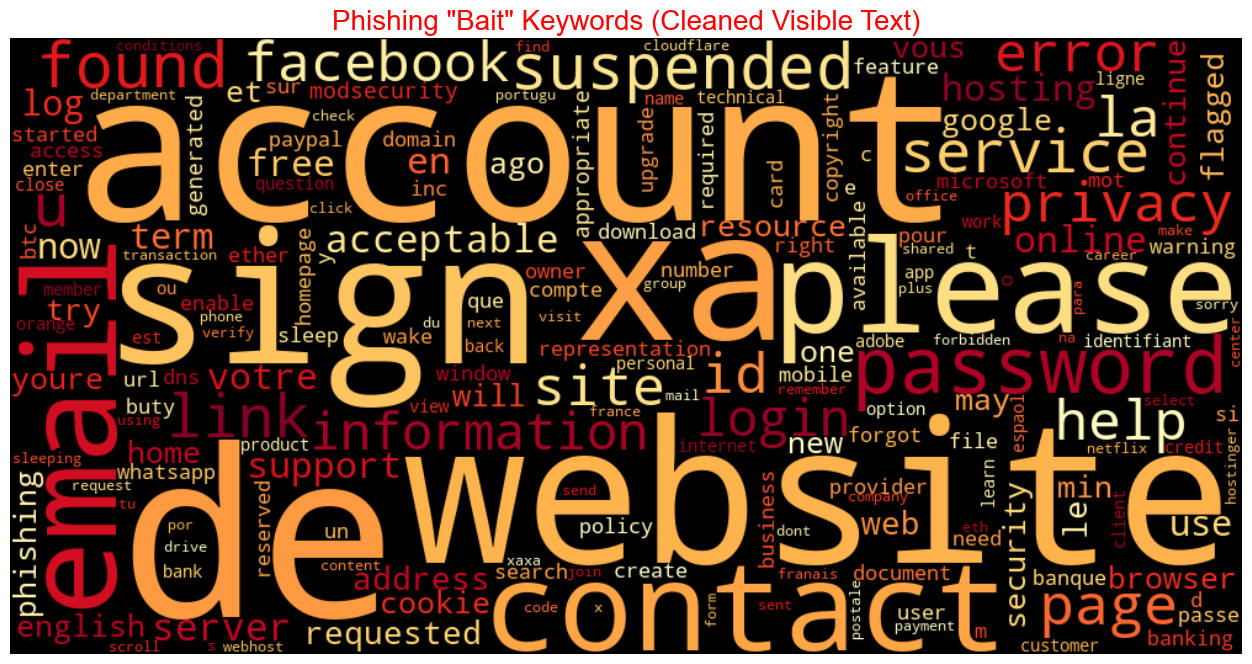

In [18]:
# Cell 10: WordCloud Generation
print("Generating Cleaned WordClouds...")
phish_text = " ".join(df_final[df_final['Label']==1]['Text_Content'].sample(min(2000, len(df_final[df_final['Label']==1]))))

custom_sw = set(STOPWORDS)
custom_sw.update(['javascript', 'void', 'null', 'function', 'var', 'display', 'none'])

wc = WordCloud(width=1000, height=500, background_color='black', 
               colormap='YlOrRd', stopwords=custom_sw, collocations=False).generate(phish_text)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation='bilinear')
plt.title('Phishing "Bait" Keywords (Cleaned Visible Text)', fontsize=20, color='red')
plt.axis('off')
plt.savefig(os.path.join(REPORT_DIR, '3_html_wordcloud_clean.png'))
plt.show()

## 5. Dimensionality Reduction (PCA & t-SNE)
Projecting the multi-dimensional feature space into 2D to observe the separability of the classes prior to modeling.

Calculating Dimensionality Reductions...


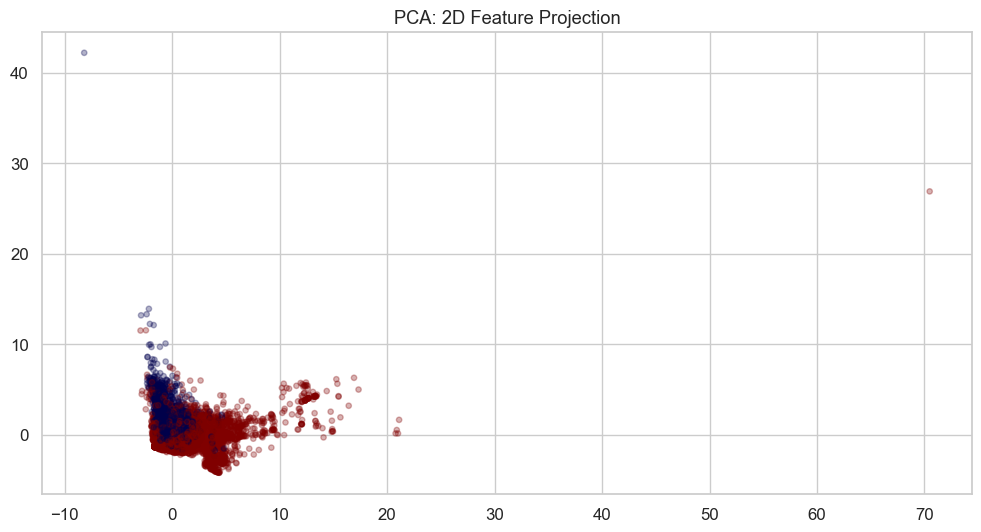

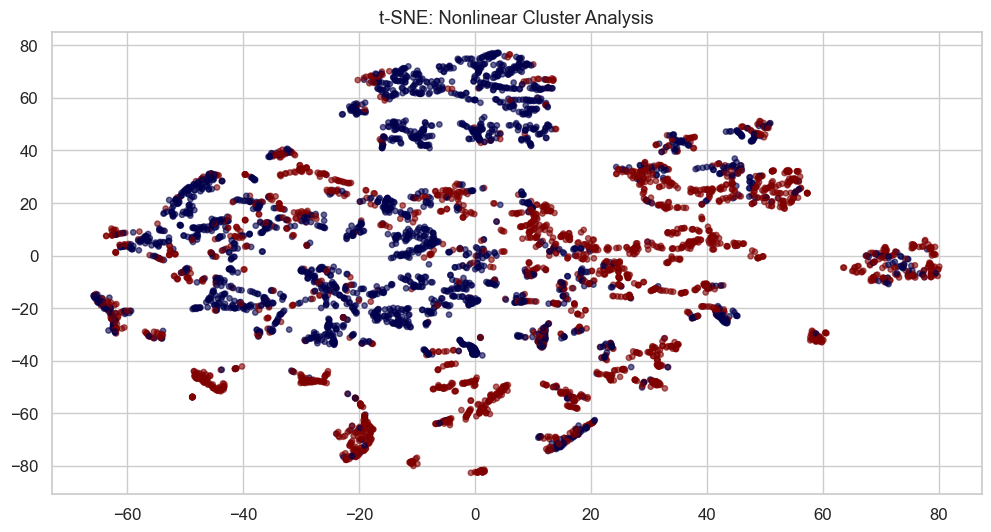

✅ EDA Complete! All reports saved to the `reports/eda/` directory.


In [19]:
# Cell 12: PCA and t-SNE
print("Calculating Dimensionality Reductions...")
X_scaled = StandardScaler().fit_transform(X_num)

# PCA
pca = PCA(n_components=2).fit_transform(X_scaled)
plt.figure(figsize=(12, 6))
plt.scatter(pca[:, 0], pca[:, 1], c=df_final['Label'], cmap='seismic', alpha=0.3, s=15)
plt.title('PCA: 2D Feature Projection')
plt.savefig(os.path.join(REPORT_DIR, '4_pca_projection.png'))
plt.show()

# t-SNE (Sampled for speed)
sample_size = min(5000, len(X_scaled))
tsne = TSNE(n_components=2, random_state=42).fit_transform(X_scaled[:sample_size])
plt.figure(figsize=(12, 6))
plt.scatter(tsne[:, 0], tsne[:, 1], c=df_final['Label'].iloc[:sample_size], cmap='seismic', alpha=0.6, s=15)
plt.title('t-SNE: Nonlinear Cluster Analysis')
plt.savefig(os.path.join(REPORT_DIR, '5_tsne_projection.png'))
plt.show()

print("✅ EDA Complete! All reports saved to the `reports/eda/` directory.")